In [1]:
from pathlib import Path
import json
import matplotlib as mpl
import matplotlib.pyplot as plt

EXPORT_ROOT = Path("paper_exports")
EXPORT_TABLES = EXPORT_ROOT / "tables"
EXPORT_FIGS = EXPORT_ROOT / "figures"
EXPORT_LOGS = EXPORT_ROOT / "logs"
for p in [EXPORT_ROOT, EXPORT_TABLES, EXPORT_FIGS, EXPORT_LOGS]:
    p.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 900,
    "savefig.transparent": False,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.35,
    "font.size": 10
})

print("Figures:", EXPORT_FIGS.resolve())
print("Tables:", EXPORT_TABLES.resolve())
print("Logs:", EXPORT_LOGS.resolve())

cr = Path("current_run.txt")
run_rel = cr.read_text().strip()
RUN_PATH = Path("experiments") / Path(run_rel)

CONFIG_PATH = RUN_PATH / "config.json"
if not CONFIG_PATH.exists():
    raise RuntimeError(f"config.json not found at {CONFIG_PATH}. Make sure the run is prepared.")

CONFIG = json.load(open(CONFIG_PATH))
RESULTS_PATH = RUN_PATH / "results"


Figures: C:\Users\aratb\Desktop\submitted_multimodal_realestate_ml_public\paper_exports\figures
Tables: C:\Users\aratb\Desktop\submitted_multimodal_realestate_ml_public\paper_exports\tables
Logs: C:\Users\aratb\Desktop\submitted_multimodal_realestate_ml_public\paper_exports\logs


#### common helper methods for ablation runs

In [2]:
import numpy as np
import pandas as pd
import time
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.base import clone

df_w = pd.read_csv("1-transaction-data/price_series.csv", index_col="date", parse_dates=True)
counts_df = pd.read_csv("1-transaction-data/counts_series.csv", index_col="date", parse_dates=True)
sent_df = pd.read_csv("2-sentiment-data/nsi_features_smooth.csv", index_col="date", parse_dates=True)
sar_df = pd.read_csv("3-satellite-data/weekly_sar_aligned.csv", index_col="date", parse_dates=True)
ir_series = pd.read_csv("4-interest-rate-data/interest_rate_series.csv", index_col="date", parse_dates=True).squeeze("columns")

sar_df = sar_df.reindex(df_w.index).ffill()
sent_df = sent_df.reindex(df_w.index).ffill()
ir_series = ir_series.reindex(df_w.index).ffill()

selected_master_projects = [
    "Business Bay", "DAMAC HILLS 2", "DAMAC HILLS", "TOWN SQUARE", "DownTown Dubai",
    "Dubai Creek Harbour", "Dubai Marina", "Dubai South Residential District",
    "Dubai Sports City", "Al Furjan", "International City Phase 1", "Jumeirah Lakes Towers",
    "Jumeirah Village Circle", "Jumeirah Village Triangle", "Jumeriah Beach Residence  - JBR",
    "Mudon", "Palm Jumeirah", "Silicon Oasis", "The Greens"
]

region_targets = ["Dubai Marina"]

sent_cols = [
    c for c in sent_df.columns
    if c == "nsi_value" or c.startswith("nsi_") or (c.startswith("sem_pca") and c.endswith("_smooth"))
]

region_sat_cols = {r: [c for c in sar_df.columns if c.startswith(f"{r}__")] for r in region_targets}

window = 12
horizons = [2, 6, 10, 14, 18, 22, 26, 30, 34]

modalities_order = ["P", "C", "S", "B", "I", "G"]
order_index = {m: i for i, m in enumerate(modalities_order)}

def canonicalize_tag(tag):
    letters = sorted(list(set(tag)), key=lambda x: order_index[x])
    return "".join(letters)

def build_flat_ir(tag, h, tgt):
    X = []
    y = []
    d = []
    sat_cols = region_sat_cols.get(tgt, [])
    for i in range(window, len(df_w) - h):
        d.append(df_w.index[i])
        parts = []
        if "P" in tag:
            parts.append(df_w[tgt].iloc[i - window:i].values)
        if "C" in tag:
            parts.append(counts_df[tgt].iloc[i - window:i].values)
        if "S" in tag:
            parts.append(sent_df.iloc[i][sent_cols].values)
        if "B" in tag and sat_cols:
            parts.append(sar_df.iloc[i][sat_cols].values)
        if "I" in tag:
            parts.append(ir_series.iloc[i - window:i].values)
        if "G" in tag:
            parts.append(df_w["Global"].iloc[i - window:i].values)
            parts.append(counts_df["Global"].iloc[i - window:i].values)
        if not parts:
            continue
        X.append(np.hstack(parts))
        y.append(df_w[tgt].iloc[i + h])
    if len(X) == 0:
        return np.zeros((0, 0)), np.zeros((0,)), pd.DatetimeIndex([])
    return np.vstack(X), np.array(y), pd.DatetimeIndex(d)

def make_rolling_folds(idx, n_folds=10, train_years=5, val_months=6,
                       start=pd.Timestamp("2015-09-01"), end=pd.Timestamp("2025-10-01")):
    folds = []
    cur = start
    for _ in range(n_folds):
        train_end = cur + pd.DateOffset(years=train_years)
        val_end = train_end + pd.DateOffset(months=val_months)
        if val_end > end:
            break
        tr = (idx >= cur) & (idx < train_end)
        va = (idx >= train_end) & (idx < val_end)
        if tr.sum() > 0 and va.sum() > 0:
            folds.append((tr, va, cur, train_end, val_end))
        cur = cur + pd.DateOffset(months=val_months)
    return folds

knn_pipe = Pipeline([
    ("sc", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=7, weights="uniform", leaf_size=30, p=1, n_jobs=-1))
])

def eval_knn_tag_mae(tag_label, tick_every=50):
    tag = canonicalize_tag(tag_label)
    maes_all = []
    total_local = len(region_targets) * len(horizons)
    done_local = 0
    t0 = time.perf_counter()
    print(f"[Start] {tag_label} (canonical={tag})")
    for reg in region_targets:
        for h in horizons:
            Xf, yf, idx = build_flat_ir(tag, h, reg)
            if Xf.shape[0] == 0 or Xf.shape[1] == 0:
                done_local += 1
                continue
            folds = make_rolling_folds(idx)
            for tr, va, _, _, _ in folds:
                mdl = clone(knn_pipe).fit(Xf[tr], yf[tr])
                pred = mdl.predict(Xf[va])
                maes_all.append(mean_absolute_error(yf[va], pred))
            done_local += 1
            if tick_every is not None and tick_every > 0:
                if done_local % tick_every == 0 or done_local == total_local:
                    pct = 100.0 * done_local / total_local
                    print(f"  [{tag_label}] {done_local}/{total_local} ({pct:.1f}%)")
    elapsed = time.perf_counter() - t0
    print(f"[Done ] {tag_label} in {elapsed:.1f}s")
    if len(maes_all) == 0:
        return np.nan
    return float(np.mean(maes_all))


# Predictions

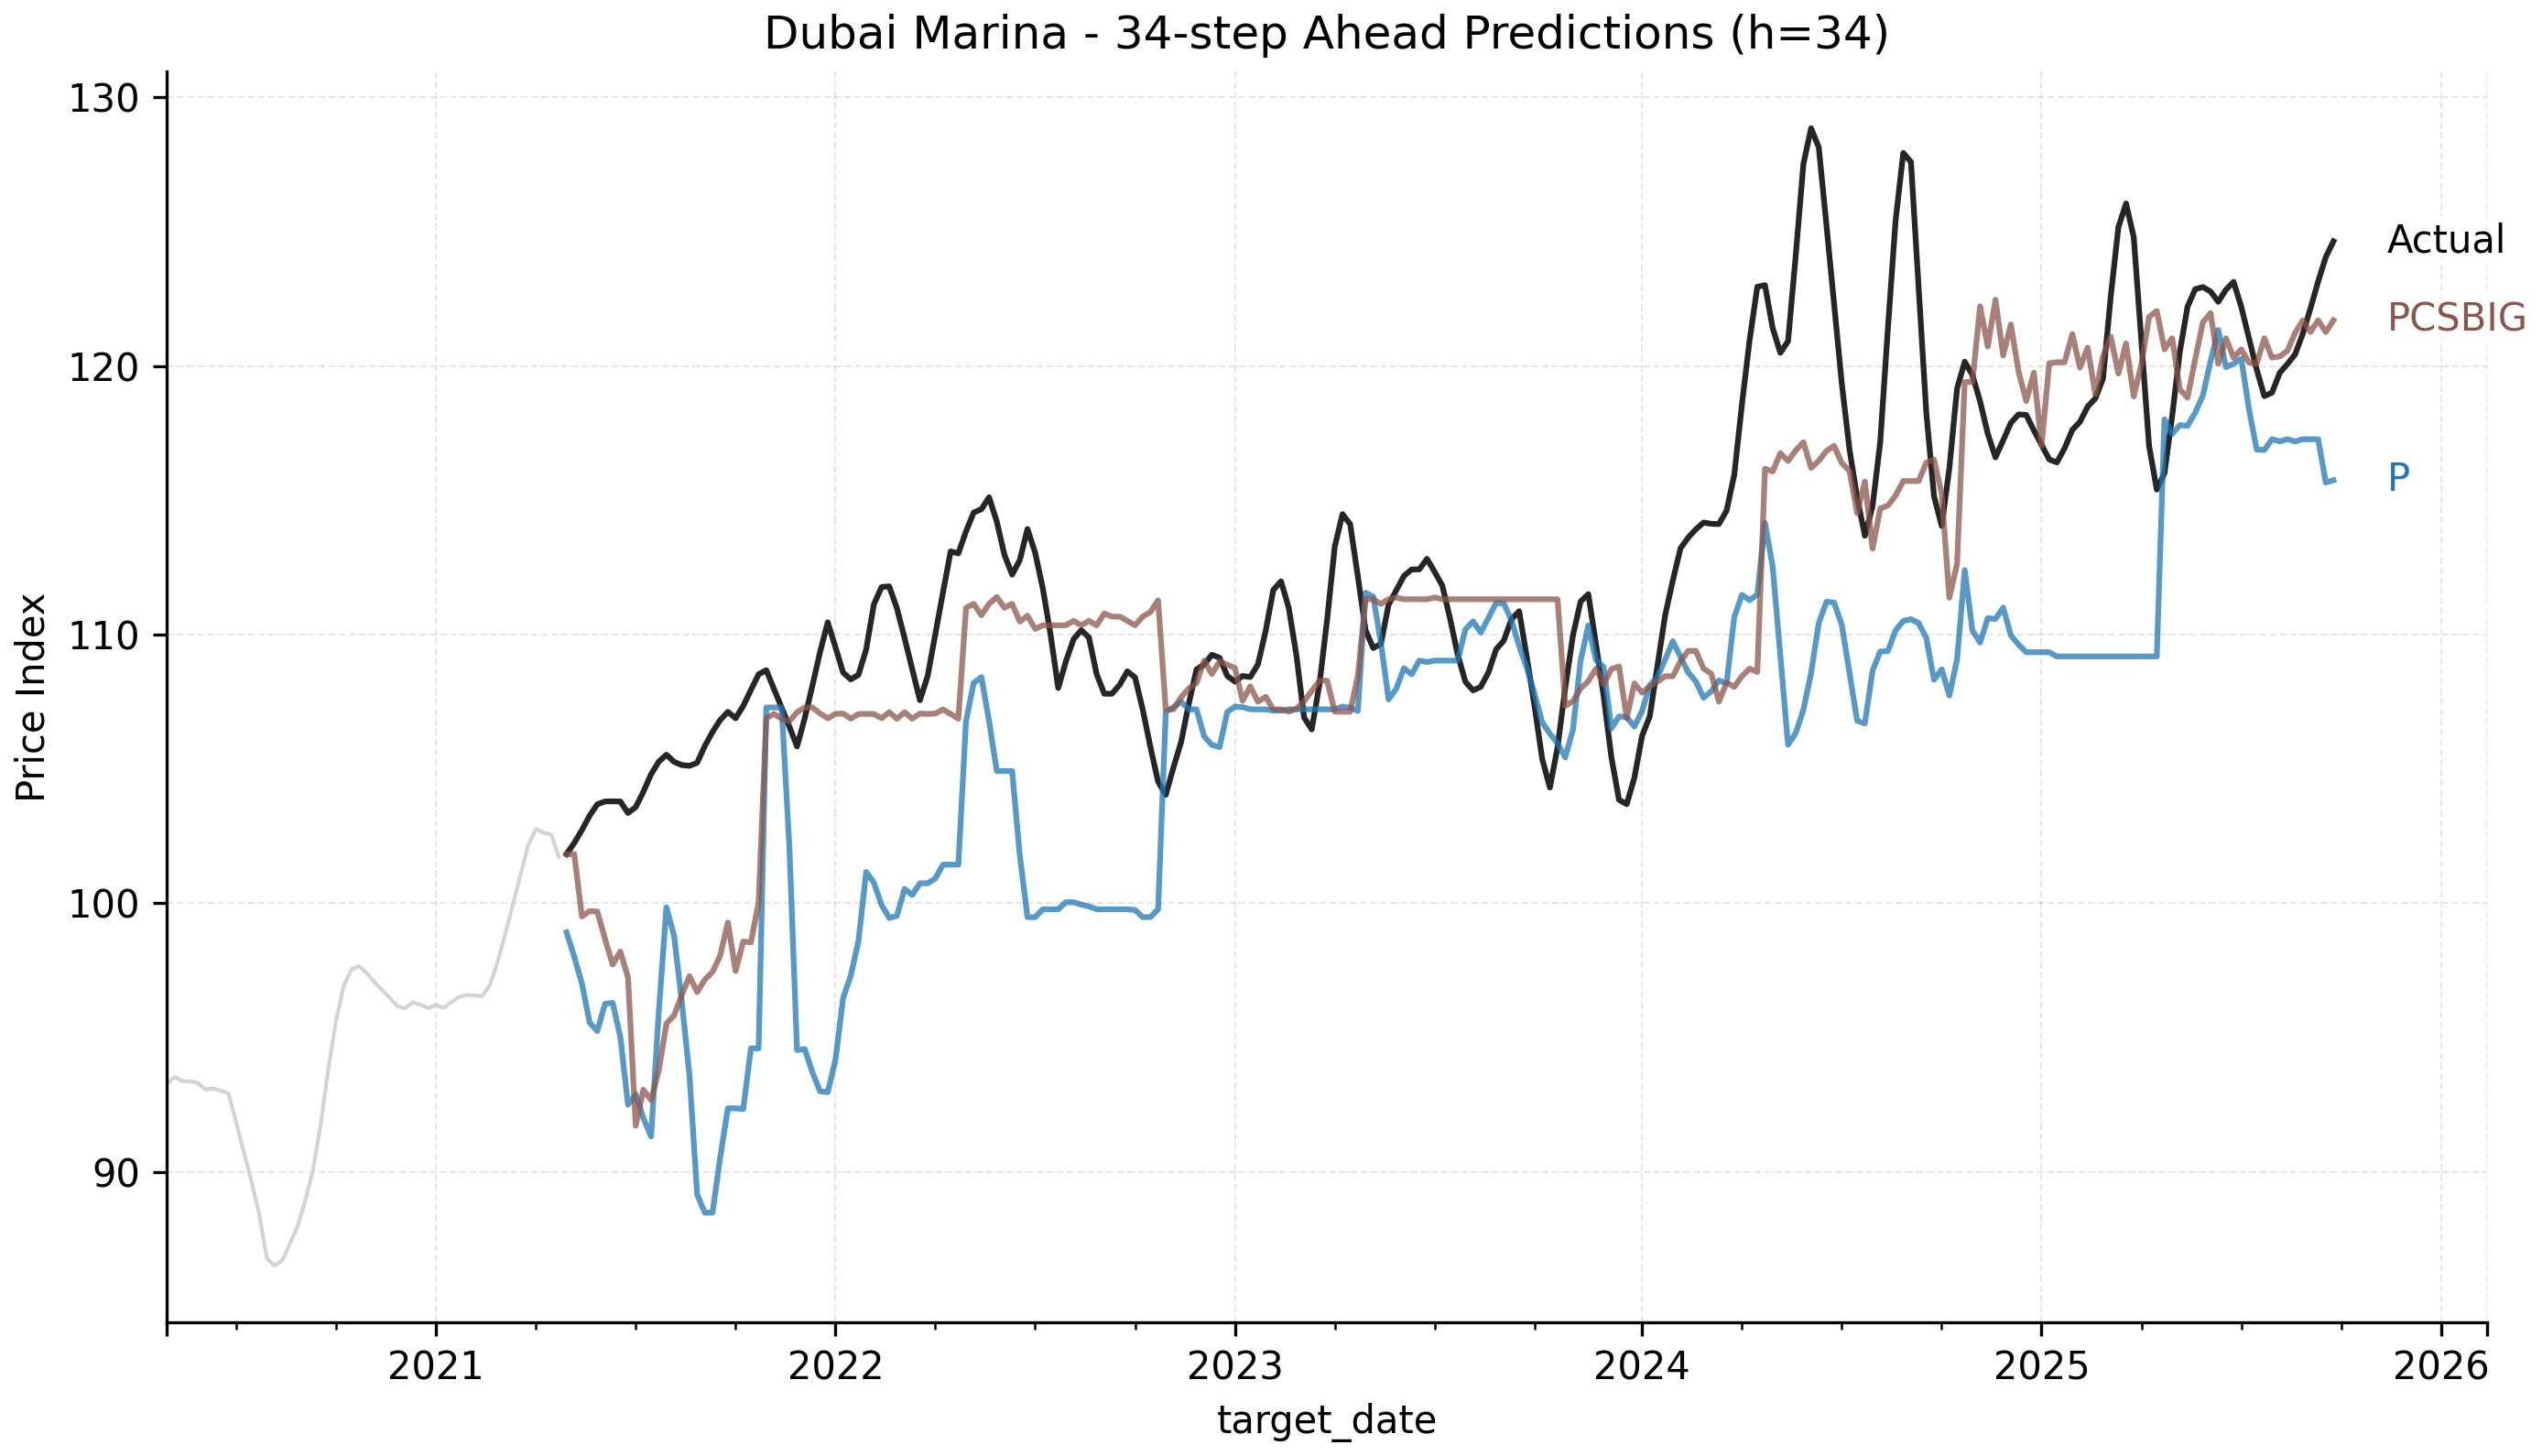

Saved figure -> paper_exports\figures\predictions_KNN_Dubai Marina_h34_P-PCSBIG.png


In [3]:
from pathlib import Path
from collections import OrderedDict
import json

region = "Dubai Marina"
tags_of_interest = ["P","PCSBIG"]
model = "KNN"
horizon = 34
title_prefix = f"{region} - {horizon}-step Ahead Predictions"

cr = Path("current_run.txt")
RUN_PATH = Path("experiments") / Path(cr.read_text().strip())

CONFIG = json.load(open(RUN_PATH / "config.json"))
horizons_available = CONFIG["horizons"]

PRED_DIR = RUN_PATH / "predictions" / model

df_w = pd.read_csv(CONFIG["data_paths"]["price_series"], index_col="date", parse_dates=True)
if region not in df_w.columns:
    raise ValueError(f"Region '{region}' not found in price series columns.")
step = df_w.index[1] - df_w.index[0]
series_actual = df_w[region]

cmap = mpl.colormaps.get_cmap("tab10").resampled(max(3, len(tags_of_interest)))
tag_palette = dict(zip(tags_of_interest, cmap(range(len(tags_of_interest)))))

def detect_fold_column(df):
    for c in ["cv", "fold", "cv_fold", "split", "fold_idx", "fold_id"]:
        if c in df.columns:
            return c
    return None

def stitch_validation(df_sel, fold_col):
    df_sel = df_sel.copy()
    df_sel["target_date"] = pd.to_datetime(df_sel["date"]) + df_sel["horizon"] * step
    if fold_col is None:
        return df_sel.groupby("target_date")["predicted"].mean().sort_index()
    g = df_sel.groupby(fold_col)
    fold_order = g["target_date"].min().sort_values().index.tolist()
    keep = OrderedDict()
    for fid in fold_order:
        gi = g.get_group(fid).sort_values("target_date")
        for td, pred in zip(gi["target_date"].to_numpy(), gi["predicted"].to_numpy()):
            if td not in keep:
                keep[td] = pred
    if not keep:
        return pd.Series(dtype=float)
    idx = pd.DatetimeIndex(list(keep.keys()))
    vals = np.array(list(keep.values()))
    return pd.Series(vals, index=idx).sort_index()

stitched = {}
missing = []
for tag in tags_of_interest:
    fp = PRED_DIR / f"{tag}__{region}__cv.parquet"
    if not fp.exists():
        missing.append(str(fp))
        continue
    dfp = pd.read_parquet(fp)
    req = {"date","model","horizon","predicted"}
    if not req.issubset(dfp.columns):
        continue
    sel = dfp[(dfp["model"] == model) & (dfp["horizon"] == horizon)]
    if sel.empty:
        continue
    fold_col = detect_fold_column(sel)
    ser = stitch_validation(sel, fold_col)
    if not ser.empty:
        stitched[tag] = ser


pred_start = min(s.index.min() for s in stitched.values())
pred_end = max(s.index.max() for s in stitched.values())
ctx_start = max(series_actual.index.min(), pred_start - pd.DateOffset(years=1))
ctx_end = min(series_actual.index.max(), pred_end)

fig, ax = plt.subplots(figsize=(9.5, 5.5))
series_actual.loc[ctx_start:pred_start - pd.Timedelta(days=1)].plot(ax=ax, color="lightgray", linewidth=1)
series_actual.loc[pred_start:ctx_end].plot(ax=ax, color="black", linewidth=1.5, alpha=0.85)

final_label_positions = []
for tag, ser in stitched.items():
    ser = ser.loc[pred_start:pred_end]
    ser.plot(ax=ax, color=tag_palette[tag], linewidth=1.5, alpha=0.75)
    final_label_positions.append((ser.iloc[-1], tag, tag_palette[tag], True))

actual_segment = series_actual.loc[pred_start:ctx_end]
actual_y = actual_segment.iloc[-1]
final_label_positions.append((actual_y, "Actual", "black", False))

final_label_positions.sort(key=lambda x: x[0])
y_min, y_max = ax.get_ylim()
gap = (y_max - y_min) * 0.04
adjusted_y = []
for y_val, _, _, _ in final_label_positions:
    if adjusted_y and y_val - adjusted_y[-1] < gap:
        y_val = adjusted_y[-1] + gap
    adjusted_y.append(y_val)
for i in range(len(adjusted_y) - 2, -1, -1):
    if adjusted_y[i + 1] - adjusted_y[i] < gap:
        adjusted_y[i] = adjusted_y[i + 1] - gap

right_pad = (pred_end - pred_start) / 12
ax.set_xlim(ctx_start, pred_end + right_pad)

for (_, label_text, color, is_model), adj_y in zip(final_label_positions, adjusted_y):
    ax.text(
        pred_end + right_pad * 0.35,
        adj_y,
        label_text,
        color=color,
        va="center",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.15", facecolor="white", alpha=0.7, edgecolor="none")
    )

ax.set_title(f"{title_prefix} (h={horizon})")
ax.set_xlabel("target_date")
ax.set_ylabel("Price Index")
ax.grid(alpha=0.3, linestyle="--", linewidth=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
plt.show()

EXPORT_ROOT = Path("paper_exports")
EXPORT_FIGS = EXPORT_ROOT / "figures"
EXPORT_FIGS.mkdir(parents=True, exist_ok=True)
outfile = EXPORT_FIGS / f"predictions_{model}_{region}_h{horizon}_{'-'.join(tags_of_interest)}.png"
fig.savefig(outfile, dpi=900, format="png", bbox_inches="tight", pad_inches=0.05)
print("Saved figure ->", outfile)
